# Open AR7W data from Igor

In [249]:
import scipy.io as sio
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import gsw
from scipy import integrate

In [4]:
def decimal_year_to_datetime(decimal_year):
    decimal_year = np.asarray(decimal_year)

    year = np.floor(decimal_year).astype(int)
    frac = decimal_year - year

    start_of_year = pd.to_datetime(year, format="%Y")
    start_next_year = pd.to_datetime(year + 1, format="%Y")

    # Length of year in nanoseconds (int64)
    year_length_ns = (start_next_year - start_of_year).values.astype("timedelta64[ns]").astype(np.int64)

    # Fractional offset in nanoseconds
    offset_ns = (frac * year_length_ns).astype(np.int64)

    return start_of_year.values + offset_ns.astype("timedelta64[ns]")

### Open Igor's datasets

In [6]:
data_dir = Path("/Users/mzahn/data/Labrador_AR7W/igor_ds/AR7W")

datasets = []

for matfile in sorted(data_dir.glob("*.mat")):
    # print(matfile)
    mat = sio.loadmat(matfile, squeeze_me=True, struct_as_record=False)
    Section = mat["Section"]

    # Dimensions
    station = np.arange(Section.Lat_grid.size)
    pressure = Section.V_grid

    # Convert decimal year to datetime
    time = decimal_year_to_datetime(Section.YD_grid)
    # print(time)
    ds = xr.Dataset(
        data_vars={
            "salinity": (("station", "pressure"), Section.S_grid),
            "temperature": (("station", "pressure"), Section.T_grid),
            "sigma": (("station", "pressure"), Section.Sig_grid),
            "sigma0": (("station", "pressure"), Section.Sig0grid),
            "sigma1": (("station", "pressure"), Section.Sig1grid),
            "sigma2": (("station", "pressure"), Section.Sig2grid),
        },
        coords={
            "station": station,
            "pressure": ("pressure", pressure),
            "time": ("station", time),
            "latitude": ("station", Section.Lat_grid),
            "longitude": ("station", Section.Lon_grid),
            "distance": ("station", Section.Dist_grid),
            "bottom_depth": ("station", Section.TOPO_grid),
        },
        attrs={
            "source": "Labrador Sea AR7W hydrography",
            "original_file": matfile.name,
        }
    )
    
    datasets.append(ds)

In [8]:
ds

<xarray.Dataset> Size: 478kB
Dimensions:       (station: 13, pressure: 763)
Coordinates:
  * station       (station) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure      (pressure) uint16 2kB 5 10 15 20 25 ... 3800 3805 3815 3820
    time          (station) datetime64[ns] 104B 1994-11-17T20:19:21.290326052...
    latitude      (station) float64 104B 54.75 54.95 55.1 ... 60.35 60.41 60.57
    longitude     (station) float64 104B -54.49 -54.28 -54.13 ... -48.43 -48.22
    distance      (station) float64 104B 319.2 345.6 ... 1.045e+03 1.066e+03
    bottom_depth  (station) float64 104B -240.8 -384.7 -975.0 ... -495.5 -189.5
Data variables:
    salinity      (station, pressure) float64 79kB nan nan nan ... nan nan nan
    temperature   (station, pressure) float64 79kB nan nan nan ... nan nan nan
    sigma         (station, pressure) float64 79kB nan nan nan ... nan nan nan
    sigma0        (station, pressure) float64 79kB nan nan nan ... nan nan nan
    sigma1        (station, pressure) float64 79kB nan nan nan ... nan nan nan
    sigma2        (station, pressure) float64 79kB nan nan nan ... nan nan nan
Attributes:
    source:         Labrador Sea AR7W hydrography
    original_file:  hamburg_data 1994d88 5 days.mat

In [10]:
# combine all of them
datasets = [ds.swap_dims({"station": "time"}) for ds in datasets]
ar7w_ds = xr.concat(datasets, dim="time").sortby("time")

In [15]:
# save dataset
ar7w_ds.to_netcdf("/Users/mzahn/data/Labrador_AR7W/igor_ds/AR7W_netcdf/igor_ar7w.nc")

### Open unfiltered data and clean

In [12]:
# open dataset
ar7w_ds = xr.open_dataset("/Users/mzahn/data/Labrador_AR7W/igor_ds/AR7W_netcdf/igor_ar7w.nc")

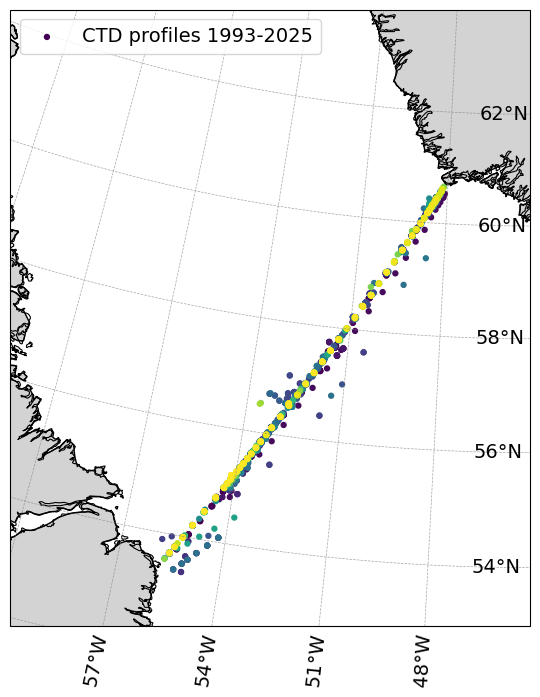

In [14]:
plt.rcParams['font.size'] = 14
fig = plt.figure(figsize=(9, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# Add map features
# ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='black', facecolor='lightgray'))
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True

# Set extent: focus on high northern latitudes (e.g., above 50N)
ax.set_extent([-60, -45, 53, 63], crs=ccrs.PlateCarree())

# Plot points for 1993
ax.scatter(
    ar7w_ds.longitude.values,
    ar7w_ds.latitude.values,
    s=50,
    # color="red", marker='.',
    c=ar7w_ds.time, marker='.',
    transform=ccrs.PlateCarree(),
    label='CTD profiles 1993-2025')

# Title and legend
# plt.title("Matching AR7W Profiles: 1993 and 2024\nSatellite SLA 2024-06-12")
plt.legend(loc='upper left')
plt.show()

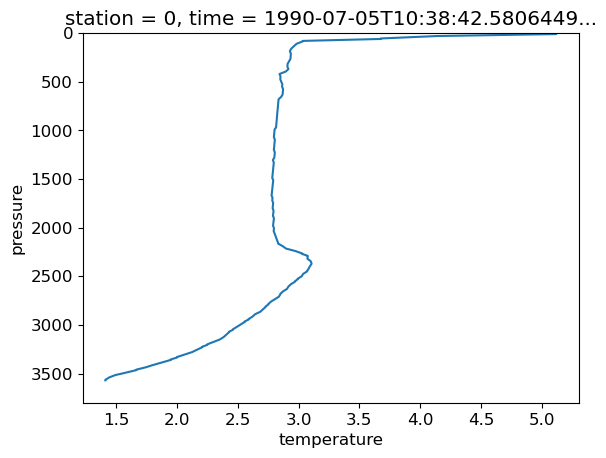

In [45]:
ar7w_ds.isel(time=0).temperature.plot(y='pressure');
plt.ylim(3800,0);

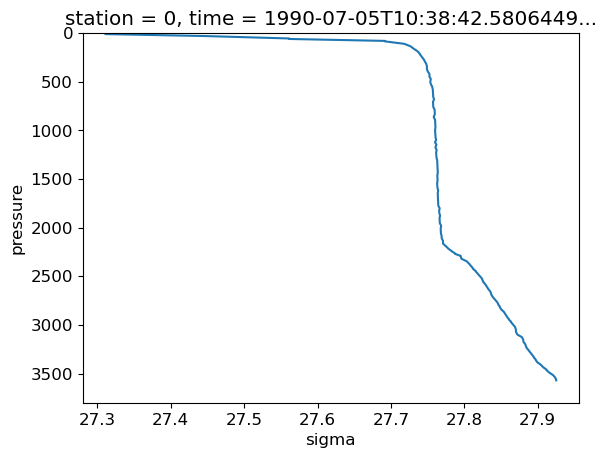

In [49]:
ar7w_ds.isel(time=0).sigma.plot(y='pressure');
plt.ylim(3800,0);

In [399]:
# calculate in situ density
ar7w_ds["rho"] = xr.DataArray(
    gsw.rho_t_exact(ar7w_ds.salinity,
                    ar7w_ds.temperature,
                    ar7w_ds.pressure),
    coords=ar7w_ds.salinity.coords,
    dims=ar7w_ds.salinity.dims)

In [401]:
# select example profile
tmp_prof = ar7w_ds.isel(time=0)

# isolate valid depths
tmp = tmp_prof.where(tmp_prof.temperature.notnull(), drop=True)

The dynamic height relative to a reference pressure $p_\mathrm{ref}$ is:

$$
D = \frac{1}{g} \int_0^{p_\mathrm{ref}} \alpha \, dp
$$

where:

- $D$ = dynamic height in meters  
- $g = 9.7963~\mathrm{m/s^2}$  
- $\alpha = \alpha_\text{in-situ} - \alpha_\text{ref}$ (specific volume anomaly)  
- $p_\mathrm{ref}$ = reference pressure

The specific volume anomaly, $\alpha$, is defined as:

$$
\alpha = \frac{1}{\rho(S, t, p)} - \frac{1}{\rho_\mathrm{ref}(p)}
$$

where:

- $\rho(S, t, p)$ = in-situ density of seawater (kg/m³)  
- $\rho_\mathrm{ref}(p)$ = density of standard seawater at reference salinity $S_\mathrm{ref} = 35.16504~\mathrm{g/kg}$ and $T_\mathrm{ref} = 0^\circ \mathrm{C}$  
- $p$ = pressure

In [253]:
from scipy.integrate import cumulative_trapezoid

In [487]:
# extract example profile data
s = tmp.salinity.values
t  = tmp.temperature.values
p  = tmp.pressure.values

# compute in situ density
rho = gsw.rho_t_exact(s, t, p)  # kg/m3

# compute specific volume of example profile
alpha = 1.0 / rho # m3/kg

# compute reference specific volume (standard seawater)
s_ref_exact = gsw.SR_from_SP(35)
s_ref = np.full_like(p, s_ref_exact)
t_ref  = np.zeros_like(p)

rho_ref = gsw.rho_t_exact(s_ref, t_ref, p)
alpha_ref = 1.0 / rho_ref

# compute specific volume anomaly
delta = alpha - alpha_ref

# convert pressure to Pa
p_pa = p * 1e4

# cumulative trapezoidal integration
dyn_height_manual = cumulative_trapezoid(delta, p_pa, initial=0)

# convert to meters
dyn_height_manual_m = dyn_height_manual / 9.7963

In [501]:
# using the gsw package
SA = gsw.SA_from_SP(s, p, tmp.longitude.values, tmp.latitude.values)
CT = gsw.CT_from_t(SA, t, p)

dyn_height_gsw = gsw.geo_strf_dyn_height(SA, CT, p, p_ref=p[-1])
dyn_height_gsw_m = dyn_height_gsw / 9.7963

In [491]:
dyn_height_manual_m[-1]

1.4779091657413206

In [493]:
dyn_height_gsw_m[0]

1.4320137122140686

In [495]:
(dyn_height_manual_m[-1] - dyn_height_gsw_m[0])*100

4.5895453527251995

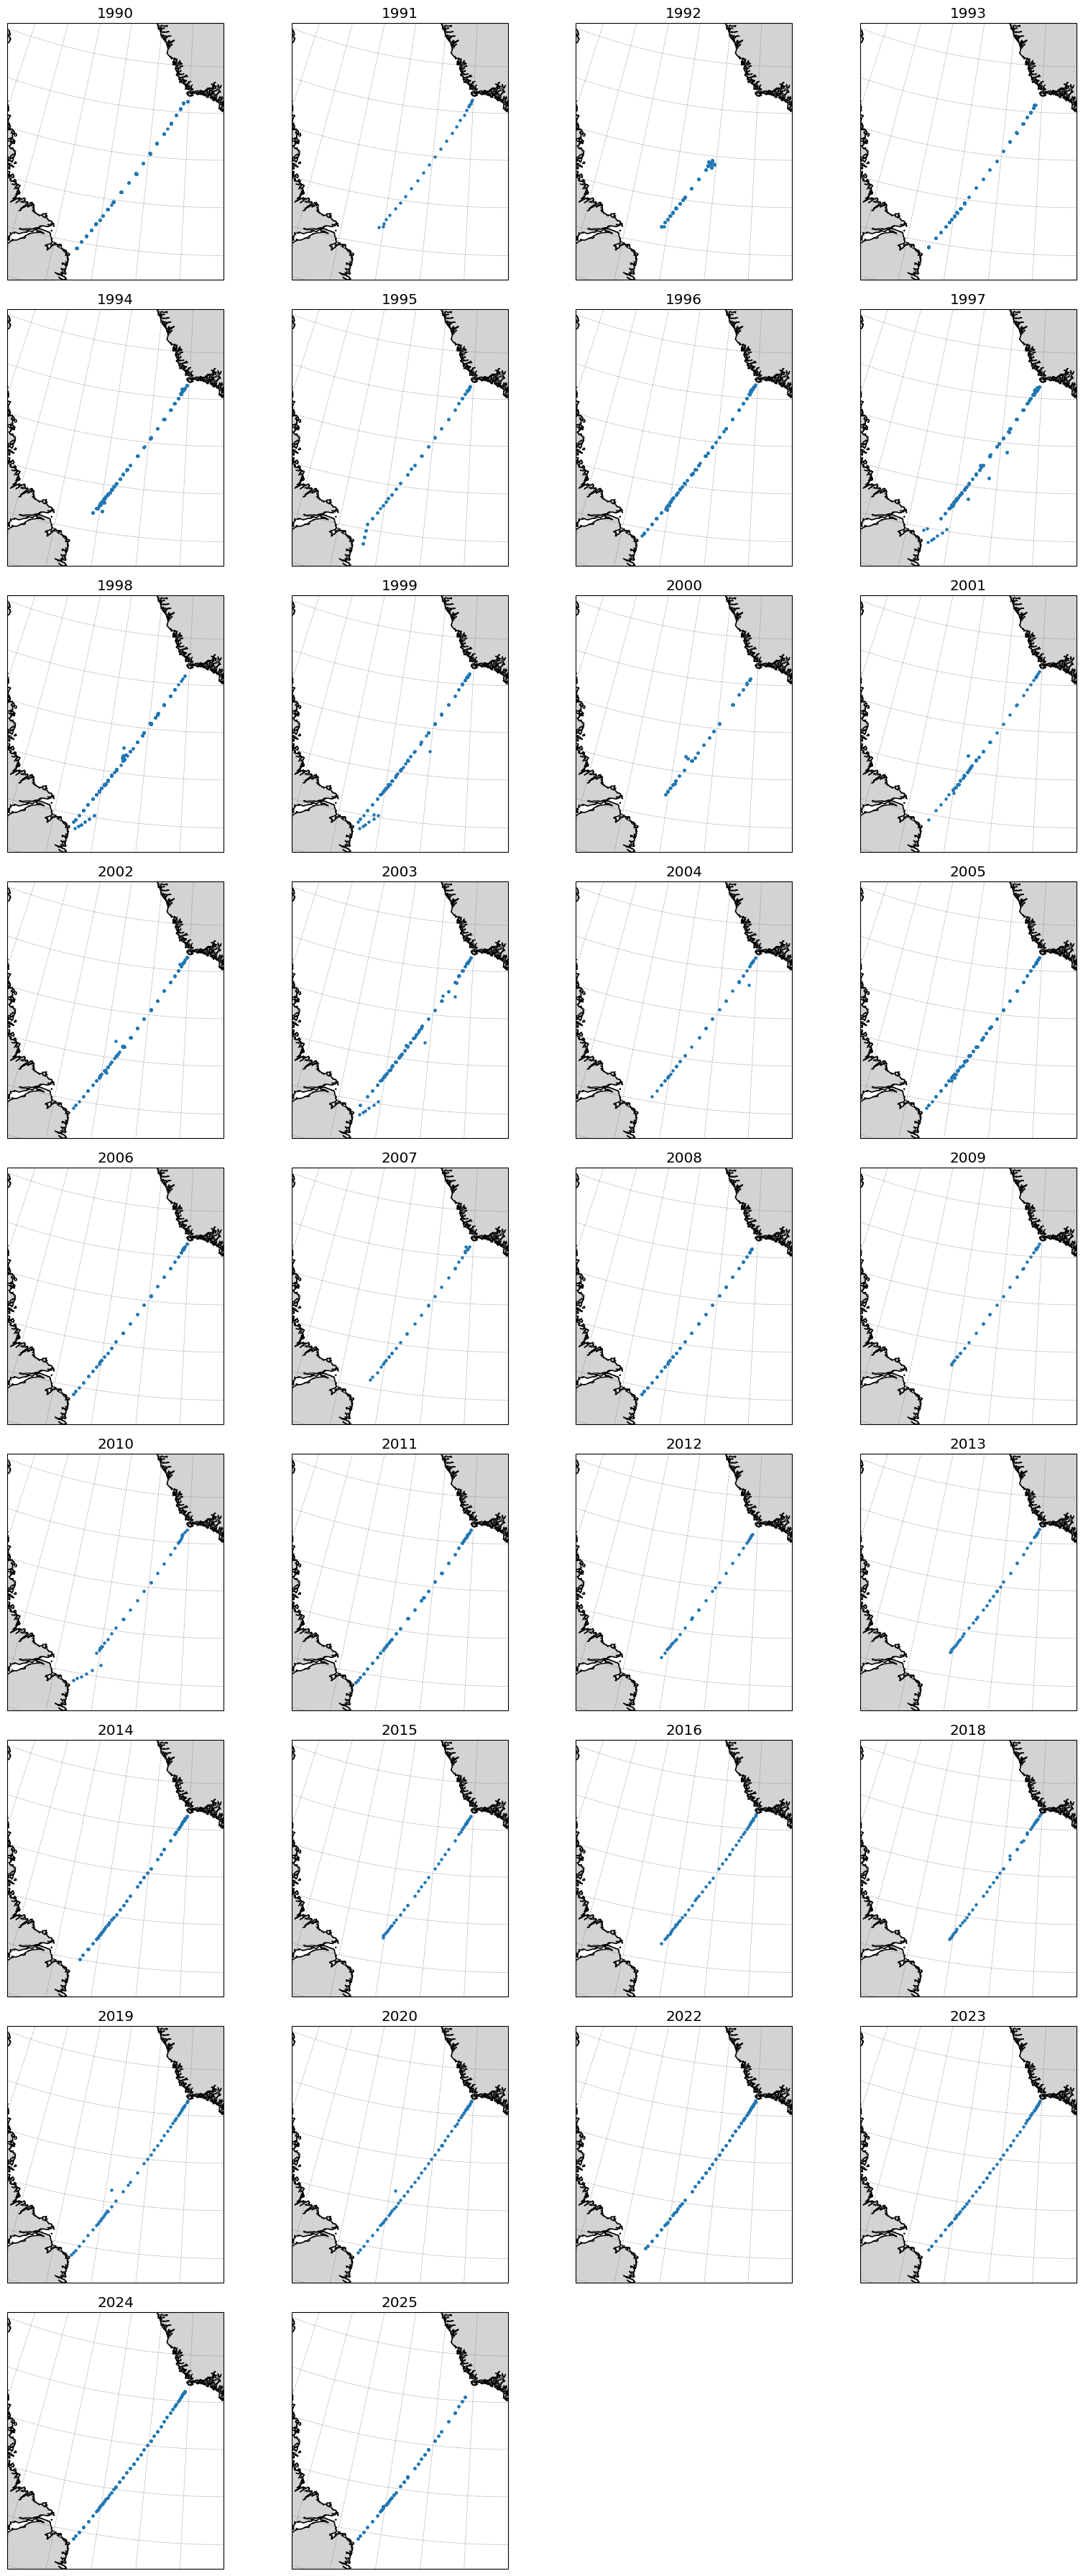

In [29]:
plt.rcParams['font.size'] = 12

# Extract years
years = np.unique(ar7w_ds['time'].dt.year.values)
n_years = len(years)

# Define subplot grid size
ncols = 4
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 4*nrows),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-45)}
)

axes = axes.flatten()  # Flatten in case of 2D array

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for this year
    yearly_ds = ar7w_ds.sel(time=str(year))

    # Map features
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '50m',
        edgecolor='black', facecolor='lightgray'))
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)

    # Gridlines
    gl = ax.gridlines(draw_labels=False,
                      linewidth=0.5, color='gray',
                      alpha=0.7, linestyle='--')

    # Set extent
    ax.set_extent([-60, -45, 53, 63], crs=ccrs.PlateCarree())

    # Scatter plot for this year
    ax.scatter(
        yearly_ds.longitude.values,
        yearly_ds.latitude.values,
        s=20,
        marker='.',
        transform=ccrs.PlateCarree()
    )

    ax.set_title(str(year))

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [343]:
tmp_clean = tmp_clean.swap_dims({'time':'distance'}).sortby('distance')

In [345]:
# Create a DataFrame of lat/lon coordinates
coords_df_clean = pd.DataFrame({
    "lat": tmp_clean.latitude.values,
    "lon": tmp_clean.longitude.values
})

# Boolean array of duplicates (True for duplicates except the first occurrence)
duplicates_clean = coords_df_clean.duplicated()

# How many duplicates are there?
print(f"Number of duplicate profiles: {duplicates.sum()}")

Number of duplicate profiles: 46


In [347]:
# Select only the first occurrence of each unique (lat, lon)
tmp_clean_unique = tmp_clean.isel(distance=~duplicates_clean)

In [351]:
tmp_clean_unique

<xarray.Dataset> Size: 2MB
Dimensions:       (distance: 47, pressure: 763)
Coordinates:
    station       (distance) int64 376B ...
  * pressure      (pressure) uint16 2kB 5 10 15 20 25 ... 3800 3805 3815 3820
    time          (distance) datetime64[ns] 376B 2024-06-09T08:54:11.61290500...
    latitude      (distance) float64 376B 53.68 53.8 53.99 ... 60.37 60.41 60.43
    longitude     (distance) float64 376B -55.54 -55.43 -55.25 ... -48.41 -48.41
  * distance      (distance) float64 376B 182.0 196.8 ... 1.045e+03 1.047e+03
    bottom_depth  (distance) float64 376B ...
Data variables:
    salinity      (distance, pressure) float64 287kB ...
    temperature   (distance, pressure) float64 287kB 5.016 3.514 ... nan nan
    sigma         (distance, pressure) float64 287kB ...
    sigma0        (distance, pressure) float64 287kB ...
    sigma1        (distance, pressure) float64 287kB ...
    sigma2        (distance, pressure) float64 287kB ...
Attributes:
    source:         Labrador Sea AR7W hydrography
    original_file:  00l3_ 2000d41 8 days.mat